# Proyecto: Bank Marketing

**Base de datos:** `Bank Marketing` — OpenML ID 222
**Enlace:** https://archive.ics.uci.edu/dataset/222/bank+marketing


## 1. Descripción de la base de datos

## Fuente y dominio del problema


El conjunto de datos proviene de las campañas de marketing directo (llamadas telefónicas) realizadas por una institución bancaria portuguesa. El banco contactó repetidamente a sus clientes por teléfono para ofrecerles la contratación de un depósito a plazo fijo (*term deposit*), un producto financiero en el que el cliente inmoviliza su dinero durante un periodo determinado a cambio de una tasa de interés. En muchos casos fue necesario más de un contacto con el mismo cliente para determinar si finalmente aceptaba o no el producto.

## Utilidad / objetivo de negocio

Las campañas de telemercadeo son costosas en tiempo y en personal, y solo una fracción de los clientes contactados termina aceptando el producto ofrecido. Por esta razón, para el banco resulta muy valioso poder anticipar qué clientes tienen mayor probabilidad de suscribir el depósito antes de llamarlos, con el fin de:

- Priorizar y dirigir los esfuerzos del call center hacia los clientes con mayor probabilidad de conversión.
- Reducir el número de llamadas innecesarias y, con ello, los costos operativos y el desgaste del cliente.
- Aumentar la tasa de éxito de las campañas futuras.
- Apoyar decisiones de segmentación de clientes para el diseño de nuevas campañas.

## Tamaño del dataset

- **Número de instancias (registros):** 45.211 clientes
- **Número de variables predictoras (features):** 16
- **Variable de salida (target):** 1
- **Valores faltantes declarados como NaN:** ninguno; sin embargo, varias variables categóricas usan la categoría "unknown" para representar información no disponible

## Variable de salida

| Variable | Tipo | Descripción |
|---|---|---|
| y | Binaria (categórica) | Indica si el cliente suscribió o no, a un depósito a plazo fijo como resultado de la campaña |

## Variables predictoras

**Nota importante señalada por los propios autores del dataset:** la variable "duration" está altamente relacionada con la variable de salida (si "duration = 0", entonces y = "no" necesariamente, porque implica que no hubo conversación). Sin embargo, la duración de la llamada **no se conoce antes de realizarla**, por lo que si el objetivo es construir un modelo predictivo realista, esta variable debería excluirse o usarse solo como referencia/benchmark. Se tendrá en cuenta esta observación en la fase de modelado.



**Datos del cliente (información demográfica y financiera):**

| Variable | Tipo | Descripción |
|---|---|---|
| age | Numérica (entera) | Edad del cliente |
| job| Categórica (12 categorías) | Tipo de ocupación (admin., blue-collar, management, technician, services, retired, self-employed, entrepreneur, unemployed, housemaid, student, unknown) |
| marital | Categórica (3 categorías) | Estado civil (married, single, divorced — divorced incluye también viudez) |
| education | Categórica (4 categorías) | Nivel educativo (primary, secondary, tertiary, unknown) |
| default | Binaria | ¿Tiene crédito actualmente en mora? (yes/no) |
| balance | Numérica (entera) | Saldo promedio anual de la cuenta, en euros |
| housing | Binaria | ¿Tiene crédito hipotecario/de vivienda? (yes/no) |
| loan | Binaria | ¿Tiene préstamo personal? (yes/no) |

**Datos relacionados con el último contacto de la campaña actual:**

| Variable | Tipo | Descripción |
|---|---|---|
| contact | Categórica (3 categorías) | Tipo de comunicación de contacto (cellular, telephone, unknown) |
| day_of_week | Numérica (entera) | Día del mes del último contacto |
| month | Categórica (12 categorías) | Mes del último contacto (jan … dec) |
| duration | Numérica (entera) | Duración del último contacto, en segundos |

**Otros atributos (historial de campañas):**

| Variable | Tipo | Descripción |
|---|---|---|
| campaign | Numérica (entera) | Número de contactos realizados durante esta campaña para este cliente (incluye el último contacto) |
| pdays | Numérica (entera) | Días transcurridos desde el último contacto de una campaña *anterior* (-1 significa que el cliente no había sido contactado antes) |
| previous | Numérica (entera) | Número de contactos realizados antes de esta campaña para este cliente |
| poutcome | Categórica (4 categorías) | Resultado de la campaña de marketing anterior (success, failure, other, unknown) |


# 2. Descripción del problema

Se trata de un problema de aprendizaje supervisado de clasificación binaria, ya que la variable objetivo `y` solo toma dos valores posibles (yes / no) y se cuenta con observaciones históricas ya etiquetadas para entrenar un modelo.

##Carga de la base de datos

In [ ]:
!pip install ucimlrepo

In [ ]:
#Librerías
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)


{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

El dataset tiene efectivamente **45.211 filas** (clientes contactados) y **17 columnas** (16 variables predictoras + 1 variable objetivo)

In [ ]:
# Construimos un único DataFrame combinando las variables predictoras (X) y la variable objetivo (y)

df = pd.concat([X, y], axis=1)

print(f"Dimensiones del dataset (filas, columnas): {df.shape}")

Dimensiones del dataset (filas, columnas): (45211, 17)


## 3. Análisis exploratorio de datos (EDA)


**Análisis preliminar:**

- Hay **7 variables numéricas** de tipo int64: age, balance, day_of_week, duration, campaign, pdays, previous.
- Hay **10 variables categóricas** de tipo object: job, marital, education, default, housing, loan, contact, month, poutcome, y.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


## Estadística descriptiva de las variables numéricas

**Análisis preliminar de cada variable numérica:**

- **age** (edad): va de 18 a 95 años, con media de 40.96 y desviación estándar de 10.62, sin valores imposibles (edades negativas o excesivas).
- **balance** (saldo promedio anual en euros): rango muy amplio, de -8.019 hasta 102.127 euros. La media (1.362) es mucho mayor que la mediana (448, valor del percentil 50%), presencia de valores atípicos clientes con saldos muy altos, e incluso saldos negativos por sobregiro.
- **day_of_week** (día del mes del contacto): va de 1 a 31, consistente con los días de un mes calendario.
- **duration** (duración de la llamada en segundos): rango de 0 a 4918 segundos equivalente a 81.966 minutos.Muestra asimetría hacia la derecha (media 258 s, mediana 180 s), es decir, la mayoría de llamadas son cortas y unas pocas son muy largas.
- **campaign** (número de contactos en la campaña actual): va de 1 a 63 contactos para un mismo cliente, con media de 2.76. La mayoría de clientes fueron contactados pocas veces, pero existen casos extremos.
- **pdays** (días desde el último contacto de una campaña previa): el valor -1 domina la distribución, lo que indica que la mayoría de clientes nunca habían sido contactados antes; el máximo es de 871 días.
- **previous** (contactos antes de la campaña actual): la mediana es 0, coherente con "pdays", mostrando que la mayoría de los clientes son "nuevos" para el banco en términos de campañas anteriores.


In [ ]:
df.describe().round(2)

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


## Estadística descriptiva de las variables categóricas

**Análisis preliminar:**

- **job** tiene 11 categorías válidas la más frecuente es blue-collar 9.732 clientes.
- **marital** tiene 3 categorías; predominan los clientes casados con 27.214 clientes.
- **education** tiene 3 categorías válidas; predomina el nivel secondary con 23.202 clientes.
- **default, housing y loan** son variables binarias; la gran mayoría de clientes **no** está en mora "default = no" .
- **contact** tiene 2 categorías válidas cellular y telephone, siendo cellular la más común.
- **month** tiene 12 categorías, con may como el mes más frecuente por un margen de 13.766 contactos.
- **poutcome** tiene 3 categorías válidas failure, other, success; entre los datos disponibles, failure es la más común 4.901 casos.
- La variable objetivo **y** es binaria, con no como la clase mayoritaria 39.922 casos.

In [ ]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,44923,45211,43354,45211,45211,45211,32191,45211,8252,45211
unique,11,3,3,2,2,2,2,12,3,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,failure,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,4901,39922


## Verificación de duplicados

In [ ]:
n_duplicados = df.duplicated().sum()
pct_duplicados = n_duplicados / len(df) * 100

print(f"Número de filas completamente duplicadas: {n_duplicados}")
print(f"Porcentaje sobre el total de registros: {pct_duplicados:.2f}%")


Número de filas completamente duplicadas: 0
Porcentaje sobre el total de registros: 0.00%


## Valores faltantes

A diferencia de lo que ocurre al leer el archivo CSV crudo directamente donde el faltante viene escrito como el texto "unknown", la función fetch_ucirepo() de la librería ucimlrepo convierte automáticamente ese "unknown" a NaN real, y por eso sí aparecen valores nulos al aplicar df.isnull() sobre **X** y **y**.

Como se observa, ahora sí aparecen valores NaN reales, concentrados exactamente en las 4 columnas que usan "unknown" como marcador de dato no disponible:

- job: 288 valores faltantes (0.64% de los registros)
- education: 1.857 valores faltantes (4.11% de los registros)
- contact: 13.020 valores faltantes (28.80% de los registros)
- poutcome: 36.959 valores faltantes (81.75% de los registros)

El resto de las columnas no presenta ningún valor faltante. En total hay 52.124 celdas con NaN en todo el dataset, lo que equivale apenas al 6.78% de todas las celdas.

Los porcentajes dejan ver una diferencia muy marcada entre columnas: `job` y `education` tienen tan pocos faltantes menos del 5% que no distorsionan la distribución original si se imputan con un valor simple, mientras que `contact` y `poutcome` tienen faltantes tan frecuentes (28.80% y 81.75%) que imputarlos de la misma manera forzaría buena parte del dataset hacia una sola categoría, perdiendo el significado real de esos vacíos.

In [ ]:
faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({'faltantes': faltantes, 'porcentaje (%)': porcentaje})
print(resumen_nulos[resumen_nulos['faltantes'] > 0])

total_nulos = df.isnull().sum().sum()
total_celdas = df.size
print(f"\nTotal de valores nulos (NaN) en el dataset: {total_nulos} "
      f"({total_nulos / total_celdas * 100:.2f}% del total de celdas)")

           faltantes  porcentaje (%)
job              288            0.64
education       1857            4.11
contact        13020           28.80
poutcome       36959           81.75

Total de valores nulos (NaN) en el dataset: 52124 (6.78% del total de celdas)


## Distribución de la variable de salida (`y`)

El dataset presenta un desbalance de clases considerable: solo el 11.70% de los clientes contactados terminó suscribiendo el depósito a plazo, frente a un 88.30% que no lo hizo. Esto es totalmente razonable en el contexto de campañas de telemercadeo la mayoría de las llamadas no se convierten en ventas

In [ ]:
vc = df['y'].value_counts()
pct = df['y'].value_counts(normalize=True) * 100
for idx in vc.index:
    print(f"y = {idx:4s} -> {vc[idx]:6d} clientes  ({pct[idx]:.2f}%)")

y = no   ->  39922 clientes  (88.30%)
y = yes  ->   5289 clientes  (11.70%)


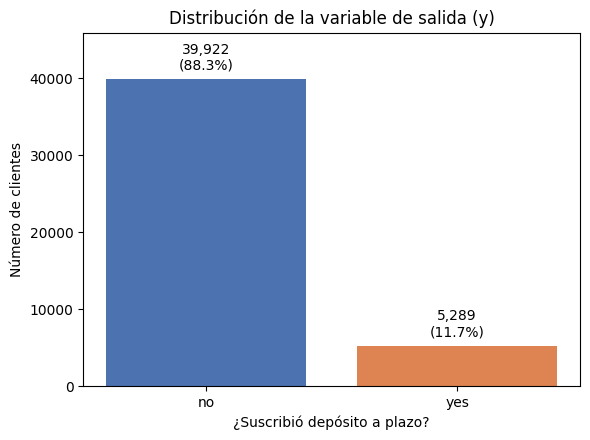

In [ ]:
counts = df['y'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4.5))

bars = ax.bar(
    counts.index,
    counts.values,
    color=['#4C72B0', '#DD8452']
)

# Agregar etiquetas
for b in bars:
    h = b.get_height()
    porcentaje = h / len(df) * 100

    ax.text(
        b.get_x() + b.get_width() / 2,
        h + counts.max() * 0.02,
        f'{h:,}\n({porcentaje:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Títulos y etiquetas
ax.set_title('Distribución de la variable de salida (y)', fontsize=12)
ax.set_ylabel('Número de clientes')
ax.set_xlabel('¿Suscribió depósito a plazo?')

# Dar espacio arriba para que no se desborden las etiquetas
ax.set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.show()

## Distribución de las variables numéricas

se confirma visualmente lo observado en la tabla de estadísticos descriptivos:

- age se aproxima a una distribución relativamente simétrica, concentrada entre 30 y 50 años.
- balance, duration, campaign y previous muestran una asimetría marcada hacia la derecha.
- pdays muestra una barra dominante en -1 clientes nunca contactados antes y una dispersión de valores positivos mucho menor.

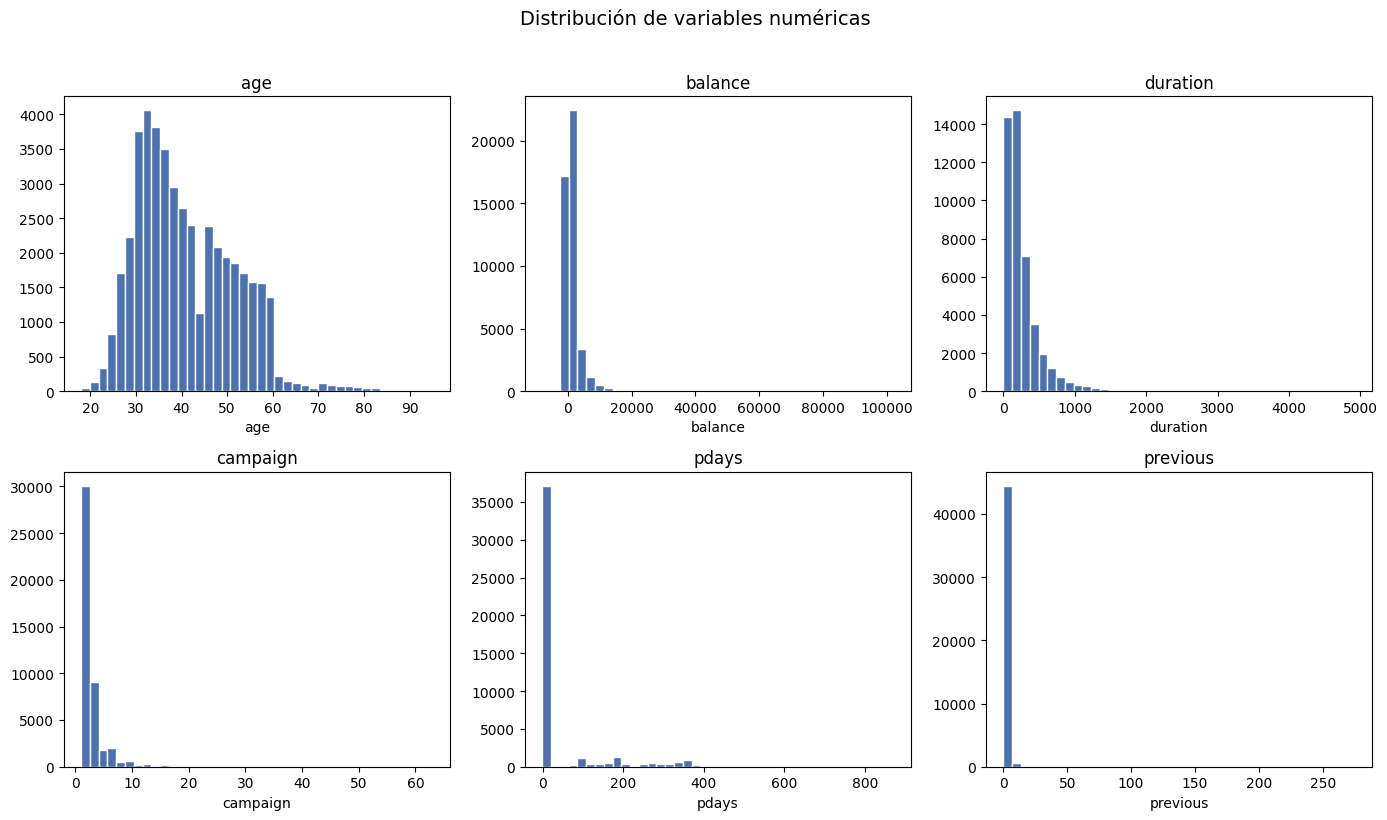

In [ ]:
num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, num_cols):
    ax.hist(df[col], bins=40, color='#4C72B0', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel(col)
plt.suptitle('Distribución de variables numéricas', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Detección de valores atípicos (outliers)

Estos valores no parecen ser errores de captura, sino casos reales extremos, por lo que se recomienda no eliminarlos directamente

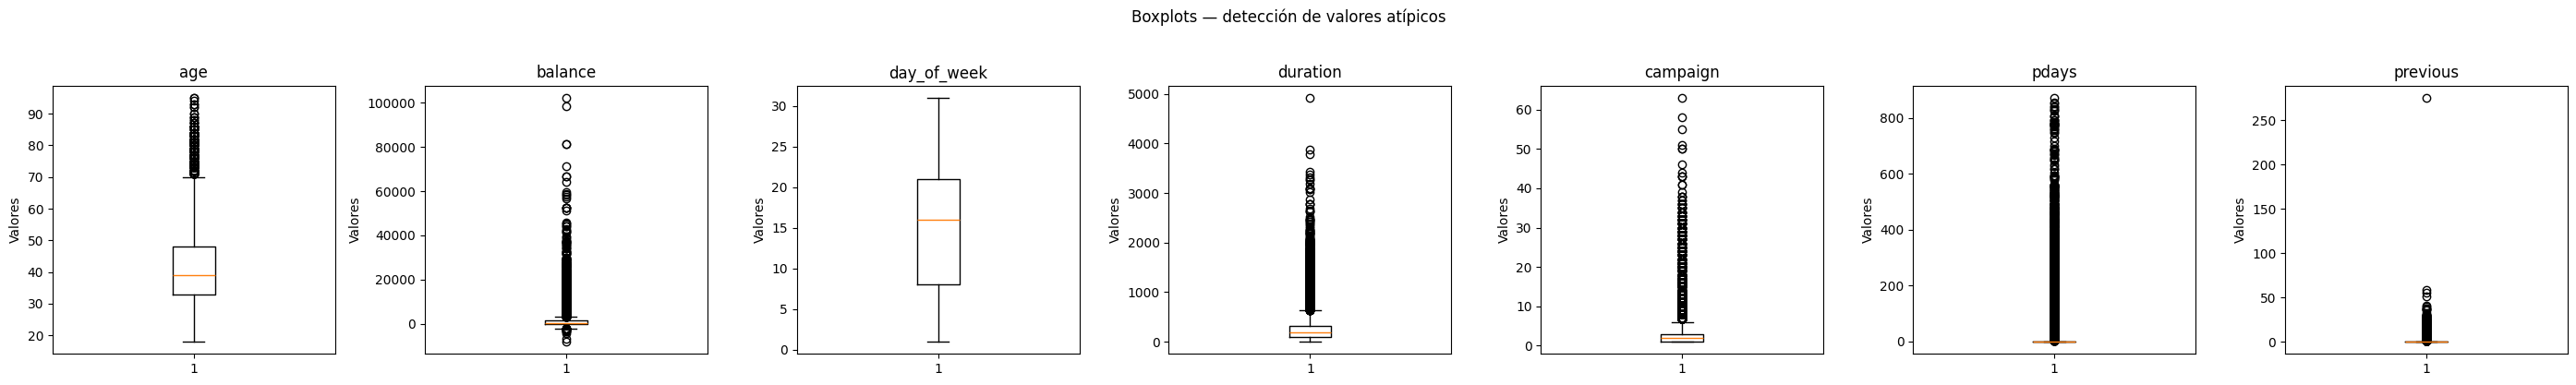

In [ ]:
# Seleccionar todas las columnas numéricas
numericas = df.select_dtypes(include='number').columns

# Crear los gráficos
fig, axes = plt.subplots(
    1,
    len(numericas),
    figsize=(4 * len(numericas), 4)
)

# Si solo hay una variable numérica
if len(numericas) == 1:
    axes = [axes]

# Crear un boxplot para cada variable
for ax, col in zip(axes, numericas):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col)
    ax.set_ylabel('Valores')

plt.suptitle(
    'Boxplots — detección de valores atípicos',
    y=1.03
)

plt.tight_layout()
plt.show()

## Distribución de las variables categóricas

- **job**: predominan `blue-collar`, `management` y `technician`; ocupaciones como `student` y `housemaid` están poco representadas.
- **education**: la mayoría tiene educación `secondary`, seguida de `tertiary`.
- **marital**: predominan ampliamente los clientes casados.
- **default**: variable muy desbalanceada en `no`, aporta poca información discriminante por sí sola.
- **contact**: predomina el contacto vía `cellular`.
- **poutcome**: entre los casos con dato disponible, predomina `failure`, seguido de `other` y `success`.

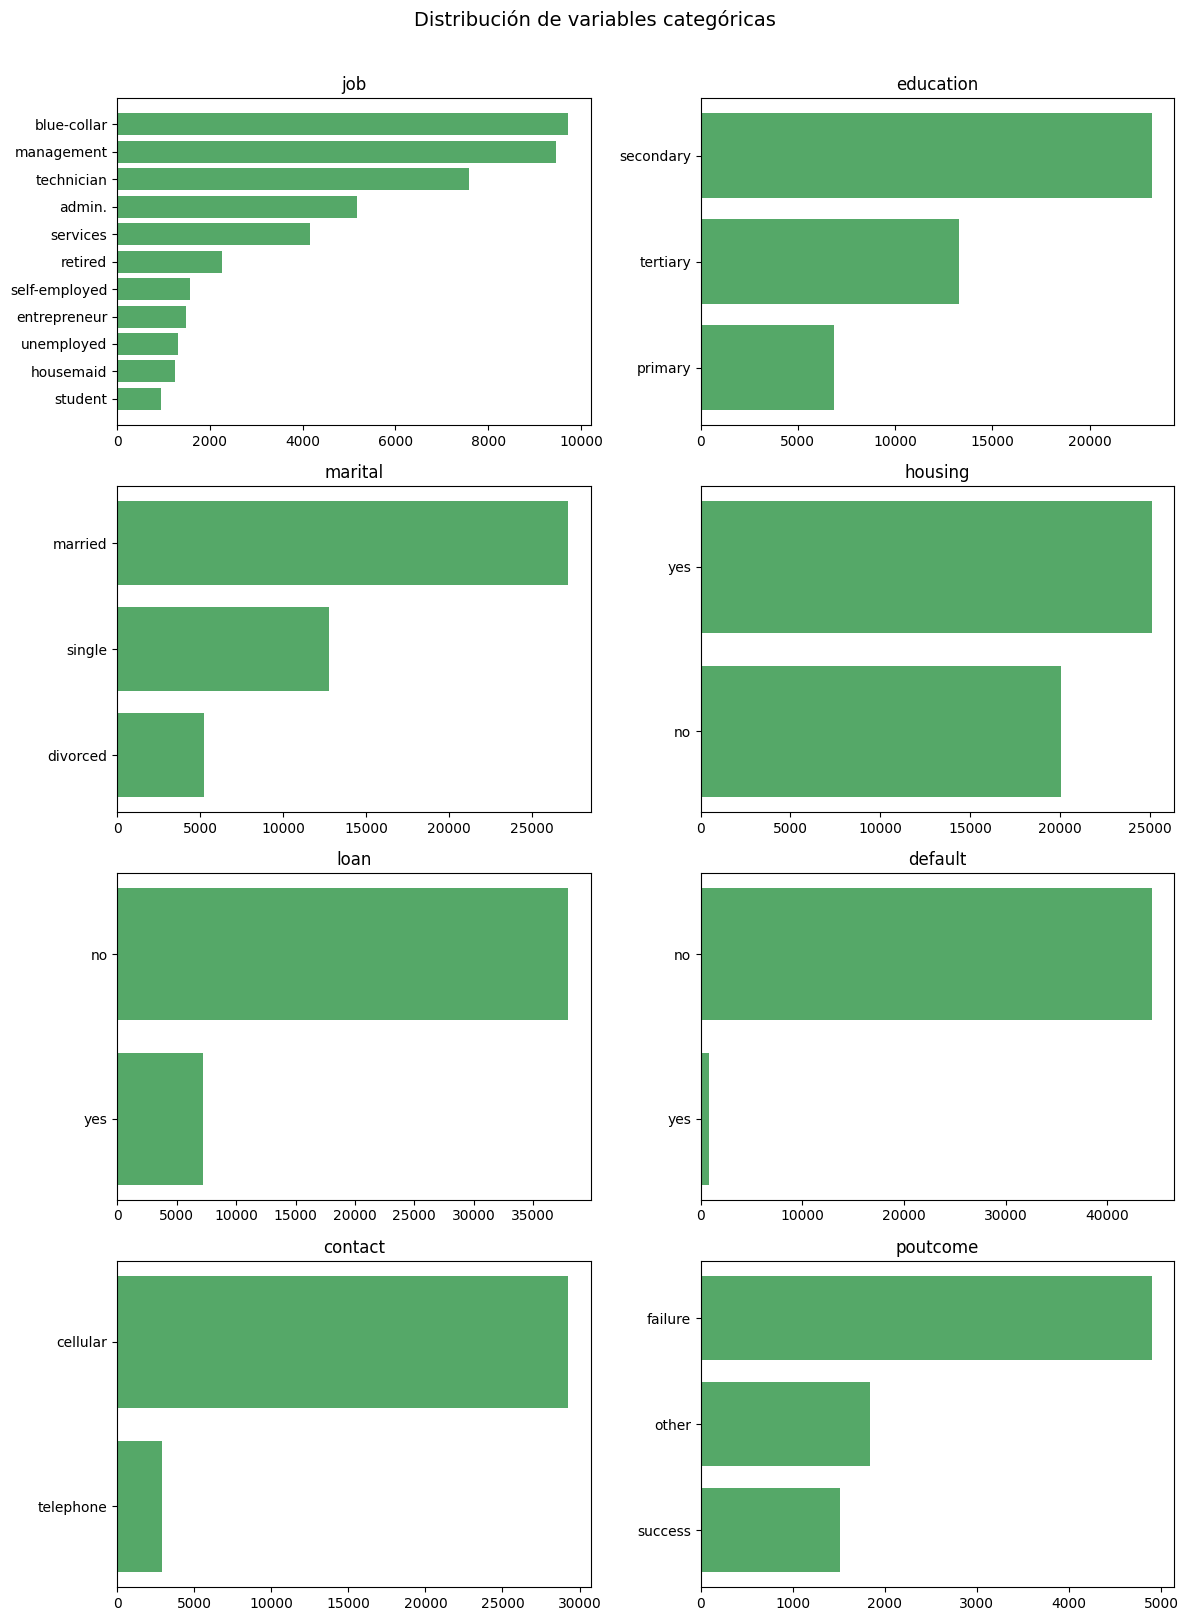

In [ ]:
cat_cols = ['job', 'education', 'marital', 'housing', 'loan', 'default', 'contact', 'poutcome']
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
for ax, col in zip(axes.flat, cat_cols):
    vc = df[col].value_counts()
    ax.barh(vc.index[::-1], vc.values[::-1], color='#55A868')
    ax.set_title(col)
plt.suptitle('Distribución de variables categóricas', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## Correlación entre variables numéricas

 las correlaciones lineales entre las variables numéricas son, en general, débiles. La más notable es la correlación positiva moderada entre `pdays` y `previous` 0.45 y 0.5

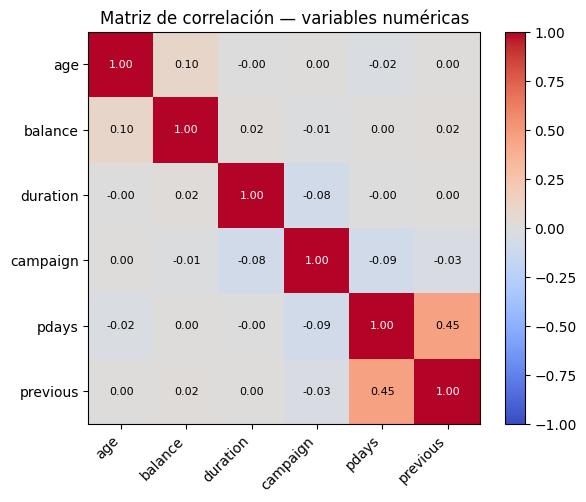

In [ ]:
num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(corr.iloc[i,j]) > 0.5 else 'black')
fig.colorbar(im)
ax.set_title('Matriz de correlación — variables numéricas')
plt.tight_layout()
plt.show()

## Tratamiento de los valores faltantes

Ya identificamos que 4 columnas tienen valores `NaN`: `job`, `education`, `contact`  y `poutcome`. El tratamiento no debe ser el mismo para todas, porque el motivo de faltantes es diferente para cada uno:

- **`job` y `education`** tienen un cantidad baja de datos faltantes y no hay evidencia de que su ausencia tenga un significado especial parecen simplemente datos no capturados. Por eso se imputan con la moda, una estrategia simple y razonable cuando la cantidad de faltantes es pequeño.
- **`contact` y `poutcome`** tienen porcentajes altos de faltantes (28.80% y 81.75%), y en ambos casos el faltante para `poutcome`, "faltante" equivale a "el cliente nunca participó en una campaña anterior" coherente con `pdays = -1` y `previous = 0`; para `contact`, equivale a que no quedó registrado el canal usado. Imputar estas columnas con la moda distorsionaría la información real, así que en su lugar se crea una categoría explícita para el faltante ("sin_campana_previa" y "no_registrado"), preservando la señal en vez de forzarla a la categoría más común.

In [ ]:
# Trabajamos sobre una copia para no perder el dataset original con NaN
df_clean = df.copy()

# job y education: bajo porcentaje de faltantes -> imputación por moda
for col in ['job', 'education']:
    moda = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(moda)
    print(f"Moda usada para imputar '{col}': {moda}")

Moda usada para imputar 'job': blue-collar
Moda usada para imputar 'education': secondary


In [ ]:
# contact y poutcome: el faltante tiene significado propio -> nueva categoría explícita
df_clean['contact'] = df_clean['contact'].fillna('no_registrado')
df_clean['poutcome'] = df_clean['poutcome'].fillna('sin_campana_previa')

print(df_clean.isnull().sum())
print(f"\nTotal de valores faltantes restantes: {df_clean.isnull().sum().sum()}")

age            0
job            0
marital        0
education      0
default        0
balance        0
housing        0
loan           0
contact        0
day_of_week    0
month          0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
y              0
dtype: int64

Total de valores faltantes restantes: 0


`df_clean` ya no tiene ningún valor faltante, y las categorías nuevas (`no_registrado`, `sin_campana_previa`) quedan disponibles como cualquier otra categoría para su utilización. De aquí en adelante, `df_clean` es la versión del dataset lista para continuar con el preprocesamiento .

In [ ]:
print(df_clean['contact'].value_counts())
print()
print(df_clean['poutcome'].value_counts())

contact
cellular         29285
no_registrado    13020
telephone         2906
Name: count, dtype: int64

poutcome
sin_campana_previa    36959
failure                4901
other                  1840
success                1511
Name: count, dtype: int64


#Carga de Datos

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)


La partición conserva el mismo desbalance del dataset original: 11.7% **yes** / 88.3% **no** tanto en `y_train` como en `y_test`, gracias al parámetro `stratify=y_bin`

In [ ]:
# Excluimos duration por la fuga de información señalada en el EDA
df_model = df_clean.drop(columns=['duration'])

# Separamos features (X) de la variable objetivo
X = df_model.drop(columns=['y'])
# Convertimos la variable objetivo de texto ('yes'/'no') a binaria
y_bin = (df_model['y'] == 'yes').astype(int)

print(f"Forma de X: {X.shape}")
print("Distribución de la clase objetivo (%):")
print((y_bin.value_counts(normalize=True) * 100).round(2))

# Dividimos en train/test (80/20).
# stratify=y_bin mantiene la misma proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, stratify=y_bin, random_state=42
)

print(f"\nFilas de entrenamiento: {X_train.shape[0]}")
print(f"Filas de prueba: {X_test.shape[0]}")


Forma de X: (45211, 15)
Distribución de la clase objetivo (%):
y
0    88.3
1    11.7
Name: proportion, dtype: float64

Filas de entrenamiento: 36168
Filas de prueba: 9043


# 4. Entrenamiento del modelo

El pipeline queda armado en un solo objeto que encadena el preprocesamiento (escalado de las numéricas + codificación one-hot de las categóricas) con la regresión logística. Al integrarlo en un Pipeline, el ajuste `fit` de `StandardScaler` y `OneHotEncoder` ocurre únicamente sobre los datos de entrenamiento de cada fold de validación cruzada, evitando que información del fold de validación se filtre al preprocesamiento.

In [ ]:
# Separamos las columnas según su tipo
columnas_numericas = ['age', 'balance', 'day_of_week', 'campaign', 'pdays', 'previous']
columnas_categoricas = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                         'contact', 'month', 'poutcome']

# - StandardScaler: estandariza las numéricas
# - OneHotEncoder: convierte cada categoría en una columna binaria
#   handle_unknown='ignore' evita que el modelo falle si aparece una categoría nueva
preprocesador = ColumnTransformer(transformers=[
    ('num', StandardScaler(), columnas_numericas),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), columnas_categoricas)
])

pipeline_logreg = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_logreg

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'balance',
                                                   'day_of_week', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome'])])),
                ('modelo', LogisticRegression(max_iter=1000, random_state=42))])

## Validación cruzada con 10 folds

Con los hiperparámetros por defecto el modelo alcanza una **accuracy de 89.24%**, pero esta cifra es engañosa dado el desbalance de clases: el **recall es de apenas 17.56%**, es decir, el modelo detecta a menos de 2 de cada 10 clientes que sí suscriben el depósito.

In [ ]:
# StratifiedKFold conserva en cada uno de los 10 folds la misma proporción
cv_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Evaluamos varias métricas a la vez porque el accuracy solo no es confiable
metricas_cv = ['accuracy', 'precision', 'recall', 'f1']

# cross_validate entrena y evalúa el pipeline completo 10 veces
resultados_cv = cross_validate(
    pipeline_logreg, X_train, y_train,
    cv=cv_10, scoring=metricas_cv, n_jobs=-1
)

print("Resultados de validación cruzada (10 folds, hiperparámetros por defecto):\n")
for m in metricas_cv:
    scores = resultados_cv[f'test_{m}']
    print(f"{m:10s}: media = {scores.mean():.4f}  |  desv. estándar = {scores.std():.4f}")

Resultados de validación cruzada (10 folds, hiperparámetros por defecto):

accuracy  : media = 0.8924  |  desv. estándar = 0.0020
precision : media = 0.6469  |  desv. estándar = 0.0244
recall    : media = 0.1756  |  desv. estándar = 0.0190
f1        : media = 0.2759  |  desv. estándar = 0.0253


## 5. Búsqueda de hiperparámetros en malla

La búsqueda en malla selecciona C=1, penalty=l1, solver= liblinear, class_weight= balanced, con un F1 promedio de 0.3737 en validación cruzada, una mejora sustancial frente al 0.276 obtenido con los hiperparámetros por defecto.

In [ ]:
param_grid = {
    'modelo__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'modelo__penalty': ['l1', 'l2'],                # tipo de penalización (Lasso / Ridge)
    'modelo__solver': ['liblinear'],                # único solver de los disponibles que soporta l1 y l2
    'modelo__class_weight': [None, 'balanced']      # 'balanced' pondera más la clase minoritaria ('yes')
}

# GridSearchCV prueba TODAS las combinaciones de la malla
grid_logreg = GridSearchCV(
    pipeline_logreg,
    param_grid=param_grid,
    cv=cv_10,
    scoring='f1',
    n_jobs=-1,
    refit=True
)

grid_logreg.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(grid_logreg.best_params_)
print(f"\nMejor F1 promedio en validación cruzada: {grid_logreg.best_score_:.4f}")

Mejores hiperparámetros encontrados:
{'modelo__C': 1, 'modelo__class_weight': 'balanced', 'modelo__penalty': 'l1', 'modelo__solver': 'liblinear'}

Mejor F1 promedio en validación cruzada: 0.3737


In [ ]:
# Revisamos el top 10 de combinaciones de hiperparámetros según su F1
resultados_grid = pd.DataFrame(grid_logreg.cv_results_)
resultados_grid = resultados_grid.sort_values('rank_test_score')

columnas_interes = ['param_modelo__C', 'param_modelo__penalty', 'param_modelo__solver',
                     'param_modelo__class_weight', 'mean_test_score', 'std_test_score', 'rank_test_score']
resultados_grid[columnas_interes].head(10)


,param_modelo__C,param_modelo__penalty,param_modelo__solver,param_modelo__class_weight,mean_test_score,std_test_score,rank_test_score
14,1.00,l1,liblinear,balanced,0.373736,0.009134,1
15,1.00,l2,liblinear,balanced,0.373504,0.009091,2
18,10.00,l1,liblinear,balanced,0.373436,0.009675,3
19,10.00,l2,liblinear,balanced,0.373351,0.009462,4
23,100.00,l2,liblinear,balanced,0.373351,0.009462,4
22,100.00,l1,liblinear,balanced,0.373351,0.009462,4
10,0.10,l1,liblinear,balanced,0.373130,0.010931,7
11,0.10,l2,liblinear,balanced,0.372049,0.008962,8
7,0.01,l2,liblinear,balanced,0.366246,0.010554,9
6,0.01,l1,liblinear,balanced,0.363828,0.007217,10


## Métricas de evaluación: Precision, Recall y F1

In [ ]:

mejor_modelo_logreg = grid_logreg.best_estimator_
y_pred_test = mejor_modelo_logreg.predict(X_test)

precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

print(f"Precision (clase 'yes'): {precision:.4f}")
print(f"Recall (clase 'yes'):    {recall:.4f}")
print(f"F1-score (clase 'yes'):  {f1:.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=['no', 'yes']))

# Extraemos el modelo final y el escalador para obtener coeficientes comparables
final_model = mejor_modelo_logreg.named_steps["modelo"]

# Obtener los nombres de las características después del preprocesamiento
# Las columnas numéricas conservan su nombre
feature_names_num = columnas_numericas
# Las columnas categóricas se expanden con OneHotEncoder
feature_names_cat = mejor_modelo_logreg.named_steps['preprocesamiento'].named_transformers_['cat'].get_feature_names_out(columnas_categoricas)

# Combinar todos los nombres de las características
all_feature_names = list(feature_names_num) + list(feature_names_cat)

coefs = pd.DataFrame({
    "feature": all_feature_names,
    "coef": final_model.coef_.ravel()
}).sort_values("coef", ascending=False)

coefs.head(10)

Precision (clase 'yes'): 0.2670
Recall (clase 'yes'):    0.6238
F1-score (clase 'yes'):  0.3739

              precision    recall  f1-score   support

          no       0.94      0.77      0.85      7985
         yes       0.27      0.62      0.37      1058

    accuracy                           0.76      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.76      0.79      9043



,feature,coef
44,poutcome_success,2.209194
36,month_mar,1.488886
39,month_oct,1.239604
31,month_dec,1.156780
40,month_sep,1.073384
11,job_retired,0.557407
35,month_jun,0.424691
14,job_student,0.396553
29,month_apr,0.341467
26,contact_cellular,0.325948


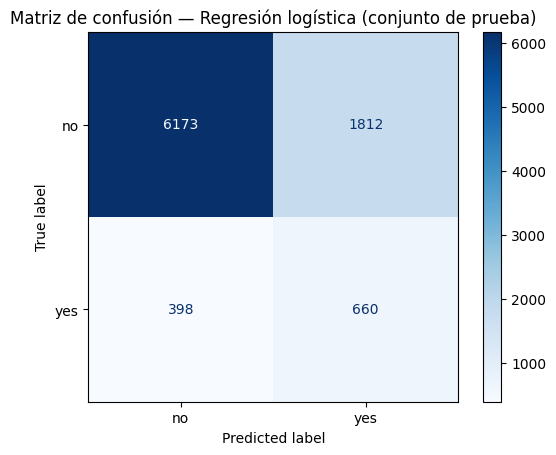

In [ ]:
# Matriz de confusión: filas = clase real, columnas = clase predicha.
matriz = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['no', 'yes'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusión — Regresión logística (conjunto de prueba)')
plt.show()

#Conclusiones

* El modelo obtiene precision = 0.267, recall = 0.624 y F1 = 0.374 para la
clase 'yes', consistente con lo observado en validación cruzada. La matriz de confusión muestra **660 verdaderos positivos** y **398 falsos negativos** de 1.058 clientes que sí suscribieron, el modelo identifica al 62%, a cambio de **1.812 falsos positivos** sobre 7.985 casos negativos. En términos de negocio, esto implica que el banco contactaría a bastantes clientes que no van a suscribir (precisión baja), pero recuperaría una proporción considerable de los que sí lo harían (recall moderado-alto), algo razonable si el costo de una llamada es bajo frente al valor de una suscripción ganada. `class_weight='balanced'` logró justamente ese objetivo: sacrificar precisión para mejorar la detección de la clase minoritaria, que es la de interés real para el banco.

* Para asegurar que el modelo de regresión logística sea verdaderamente útil y aplicable a un entorno de negocio real, la fase de preprocesamiento debe resolver simultáneamente la representatividad de los datos y la integridad de las variables. Por un lado, es imperativo aplicar técnicas de balanceo para corregir la fuerte asimetría de la variable objetivo (donde solo el 11.70% corresponde a casos de éxito), evitando así que el algoritmo genere un sesgo de predicción hacia la clase mayoritaria. Sin embargo, esta calibración matemática solo tendrá validez si se estructura tras haber excluido estrictamente la variable "duration". Al eliminar esta métrica (cuyo valor es imposible conocer antes de realizar la llamada) se previene la fuga de información. La integración de ambas medidas garantizará que el modelo no solo esté matemáticamente capacitado para detectar los depósitos a plazo, sino que sus predicciones se basen de manera exclusiva y honesta en la información disponible antes del contacto comercial.